# AI Job Market Intelligence Platform

## 2. Data Quality Analysis

### Objective

The objective of this notebook is to identify data quality issues before performing data cleaning and analysis.

### Quality checks performed:

- Missing values
- Duplicate records
- Invalid values
- Outliers
- Inconsistent categories
- Data type consistency


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


In [2]:
df = pd.read_csv("../data/raw/ai_jobs_market_2025_2026.csv")
df

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,AIJOB1496,Multimodal AI Engineer,AI Engineering,Lead (10+ yrs),8,Master's,262000.0,160000,300000,Toronto,Canada,Hybrid,SME (51-500),Retail,Python|Vision-Language Models|Fine-tuning|PyTo...,8.8,90,23.6,7.5,2026,1,1,1,0,Senior ($200-300k)
1496,AIJOB1497,NLP Engineer,AI Engineering,Senior (6-9 yrs),9,Bootcamp/Self-taught,163000.0,145000,290000,Berlin,Germany,On-site,Mid-size (501-5000),Manufacturing,Transformers|Text Processing|LLMs|Hugging Face...,6.7,91,66.5,7.8,2025,3,1,0,0,Upper-Mid ($150-200k)
1497,AIJOB1498,AI Compliance Manager,Governance,Mid (3-5 yrs),10,Master's,127000.0,100000,200000,Zurich,Switzerland,Hybrid,SME (51-500),Manufacturing,Documentation|Risk Management|Legal Knowledge|...,10.9,68,15.3,8.3,2026,3,0,1,0,Mid ($100-150k)
1498,AIJOB1499,NLP Engineer,AI Engineering,Lead (10+ yrs),4,Bachelor's,145000.0,145000,290000,Bangalore,India,Hybrid,Enterprise (5000+),Media,LLMs|Hugging Face|Python|Transformers|BERT|Tex...,8.5,91,78.8,7.4,2025,5,1,1,0,Mid ($100-150k)


In [3]:
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


## Missing Values


In [4]:
# count missing values
missing_values = df.isnull().sum()
missing_values

job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64

In [5]:
# sirf missing columns Dikhao
missing_values[missing_values > 0]
missing_values

job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64

In [6]:
# Missing Percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage[missing_percentage > 0]

Series([], dtype: float64)

## Duplicate Records

In [7]:
# Total Duplicates
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

In [8]:
# Duplicate Percentage
duplicate_percentage = (duplicate_count / len(df)) * 100
duplicate_percentage

np.float64(0.0)

## Invalid values


In [9]:
# Salary Negative To nahi ?
df[df["annual_salary_usd"] < 0]
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [10]:
# Experience Negative To Nahi?
df[df["years_of_experience"] < 0]
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [11]:
# demand score (0-10)
df[(df["demand_score"] < 0) | (df["demand_score"] > 10)]

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,AIJOB1496,Multimodal AI Engineer,AI Engineering,Lead (10+ yrs),8,Master's,262000.0,160000,300000,Toronto,Canada,Hybrid,SME (51-500),Retail,Python|Vision-Language Models|Fine-tuning|PyTo...,8.8,90,23.6,7.5,2026,1,1,1,0,Senior ($200-300k)
1496,AIJOB1497,NLP Engineer,AI Engineering,Senior (6-9 yrs),9,Bootcamp/Self-taught,163000.0,145000,290000,Berlin,Germany,On-site,Mid-size (501-5000),Manufacturing,Transformers|Text Processing|LLMs|Hugging Face...,6.7,91,66.5,7.8,2025,3,1,0,0,Upper-Mid ($150-200k)
1497,AIJOB1498,AI Compliance Manager,Governance,Mid (3-5 yrs),10,Master's,127000.0,100000,200000,Zurich,Switzerland,Hybrid,SME (51-500),Manufacturing,Documentation|Risk Management|Legal Knowledge|...,10.9,68,15.3,8.3,2026,3,0,1,0,Mid ($100-150k)
1498,AIJOB1499,NLP Engineer,AI Engineering,Lead (10+ yrs),4,Bachelor's,145000.0,145000,290000,Bangalore,India,Hybrid,Enterprise (5000+),Media,LLMs|Hugging Face|Python|Transformers|BERT|Tex...,8.5,91,78.8,7.4,2025,5,1,1,0,Mid ($100-150k)


In [12]:
# benefits score 
df[
    (df["benefits_score_10"] < 0) |
    (df["benefits_score_10"] > 10)
]
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [13]:
# salary min/max

df[df["salary_min_usd"] > df["salary_max_usd"]]
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


## Outliers
means: Aisi value jo baaki data se unusually high ya low ho

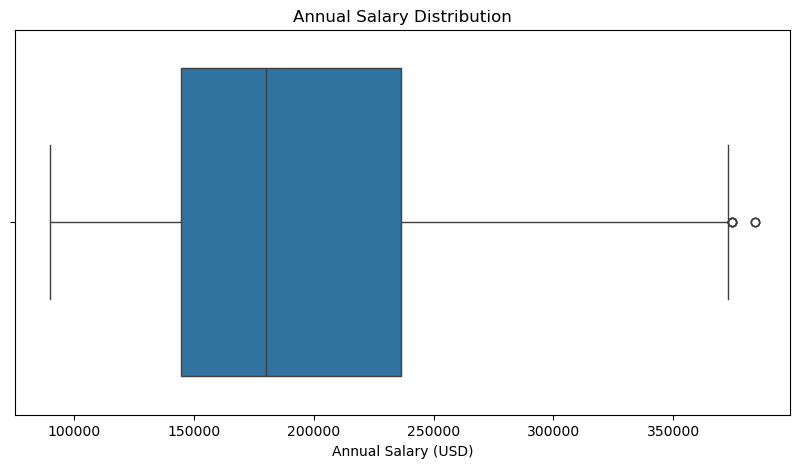

In [14]:
# Salary Distribution

plt.figure(figsize=(10,5))

sns.boxplot(x=df["annual_salary_usd"])

plt.title("Annual Salary Distribution")
plt.xlabel("Annual Salary (USD)")
plt.show()


In [15]:
# IQR Method
# IQR = Q3-Q1

Q1 = df["annual_salary_usd"].quantile(0.25)
Q3 = df["annual_salary_usd"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 144750.0
Q3: 236250.0
IQR: 91500.0
Lower Bound: 7500.0
Upper Bound: 373500.0


In [16]:
# Outliers Find Karo 
salary_outliers = df[
    (df["annual_salary_usd"] < lower_bound) |
    (df["annual_salary_usd"] > upper_bound)
]
salary_outliers

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
83,AIJOB0084,Senior ML Engineer,AI Engineering,Senior (6-9 yrs),11,Master's,374400.0,180000,312000,New York,USA,Hybrid,Big Tech (FAANG+),Consulting,MLOps|LLM Fine-tuning|System Design|Agile|Rese...,12.5,96,65.3,6.6,2026,2,1,1,0,Elite (>$300k)
647,AIJOB0648,Senior ML Engineer,AI Engineering,Senior (6-9 yrs),9,Master's,374400.0,180000,312000,Chicago,USA,Fully Remote,Big Tech (FAANG+),Automotive,System Design|LLM Fine-tuning|Distributed Syst...,13.5,96,51.4,6.5,2026,2,1,1,0,Elite (>$300k)
822,AIJOB0823,AI Solutions Architect,Architecture,Lead (10+ yrs),11,PhD,384000.0,180000,320000,Dubai,UAE,Fully Remote,Big Tech (FAANG+),Retail,Cloud|Enterprise Architecture|Python|System De...,10.4,84,14.7,6.3,2026,3,1,1,0,Elite (>$300k)
843,AIJOB0844,Senior ML Engineer,AI Engineering,Lead (10+ yrs),6,Bachelor's,374400.0,180000,312000,Paris,France,Fully Remote,Big Tech (FAANG+),Education,LLM Fine-tuning|MLOps|System Design|Python|Clo...,11.9,96,83.9,8.5,2026,3,1,1,0,Elite (>$300k)
896,AIJOB0897,AI Solutions Architect,Architecture,Lead (10+ yrs),8,PhD,384000.0,180000,320000,Toronto,Canada,On-site,Big Tech (FAANG+),Technology,Cloud|Leadership|Python|Linux|Cloud,16.4,84,15.5,9.1,2025,1,1,0,0,Elite (>$300k)
944,AIJOB0945,Senior ML Engineer,AI Engineering,Lead (10+ yrs),5,PhD,374400.0,180000,312000,Boston,USA,Hybrid,Enterprise (5000+),Healthcare,MLOps|PyTorch|Distributed Systems|System Desig...,11.7,96,19.1,9.6,2025,4,1,1,0,Elite (>$300k)
992,AIJOB0993,Senior ML Engineer,AI Engineering,Lead (10+ yrs),11,Master's,374400.0,180000,312000,Toronto,Canada,On-site,Big Tech (FAANG+),Energy,MLOps|Python|PyTorch|System Design|Leadership|...,11.5,96,73.3,6.2,2025,6,1,0,0,Elite (>$300k)
1374,AIJOB1375,AI Solutions Architect,Architecture,Lead (10+ yrs),13,Master's,384000.0,180000,320000,New York,USA,On-site,SME (51-500),Finance,Leadership|Cloud|Python|System Design|ML|Enter...,14.0,84,9.3,8.5,2025,9,1,0,0,Elite (>$300k)


In [17]:
# count
len(salary_outliers)

8

In [18]:
# Percentage
(len(salary_outliers) / len(df)) * 100


0.5333333333333333

## Inconsistent Categories

In [19]:
# Experience Level
df["experience_level"].value_counts(dropna=False)

experience_level
Entry (0-2 yrs)     385
Lead (10+ yrs)      381
Mid (3-5 yrs)       370
Senior (6-9 yrs)    364
Name: count, dtype: int64

In [20]:
#  Job Category
df["job_category"].value_counts(dropna=False)

job_category
AI Engineering      736
Data Science        127
Governance          122
Robotics             74
Product              70
Business             62
Infrastructure       55
Architecture         52
ML Operations        51
Data Engineering     51
Security             50
Research             50
Name: count, dtype: int64

In [21]:
# Remote work
df["remote_work"].value_counts(dropna=False)

remote_work
Hybrid          686
Fully Remote    445
On-site         369
Name: count, dtype: int64

In [22]:
# Country
df["country"].value_counts(dropna=False)

country
USA            515
UK              90
China           87
Canada          85
Global          82
Germany         81
Australia       78
Switzerland     76
Japan           76
Netherlands     74
Singapore       71
France          66
UAE             62
India           57
Name: count, dtype: int64

In [23]:
# Industry
df["industry"].value_counts(dropna=False)

industry
Automotive       138
Healthcare       138
Government       136
Finance          131
Retail           131
Energy           130
Consulting       126
Media            120
Education        120
Manufacturing    114
Research         110
Technology       106
Name: count, dtype: int64

In [24]:
# Better Quality Check

for column in [
    "experience_level",
    "job_category",
    "remote_work",
    "company_size",
    "industry"
]:
    print("\n", column)
    print(df[column].unique())


 experience_level
['Senior (6-9 yrs)' 'Lead (10+ yrs)' 'Entry (0-2 yrs)' 'Mid (3-5 yrs)']

 job_category
['AI Engineering' 'Data Engineering' 'Product' 'Security' 'Architecture'
 'ML Operations' 'Business' 'Robotics' 'Data Science' 'Governance'
 'Infrastructure' 'Research']

 remote_work
['On-site' 'Hybrid' 'Fully Remote']

 company_size
['Startup (1-50)' 'Enterprise (5000+)' 'Big Tech (FAANG+)' 'SME (51-500)'
 'Mid-size (501-5000)']

 industry
['Finance' 'Technology' 'Automotive' 'Government' 'Manufacturing'
 'Education' 'Retail' 'Consulting' 'Research' 'Healthcare' 'Media'
 'Energy']


In [25]:
# Boolean COlumns check

for column in ["is_senior","is_remote_friendly","is_llm_role"]:
    # print(column)
    print(df[column].value_counts(dropna=False))

is_senior
0    755
1    745
Name: count, dtype: int64
is_remote_friendly
1    1131
0     369
Name: count, dtype: int64
is_llm_role
0    1173
1     327
Name: count, dtype: int64


In [26]:
# Data Quality Summary
quality_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Duplicate Rows",
        "Total Missing Cells"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum()
        
    ]
})

quality_summary

,Metric,Value
0,Total Rows,1500
1,Total Columns,25
2,Duplicate Rows,0
3,Total Missing Cells,0


## Cleaning Plan

Based on the data quality analysis, the following actions will be performed in the data cleaning phase:

1. Handle missing values based on business context.
2. Remove exact duplicate records where appropriate.
3. Correct invalid values.
4. Standardize inconsistent categorical values.
5. Investigate salary outliers before deciding whether to retain or remove them.
6. Correct inconsistent data types.
7. Validate the cleaned dataset after transformation.